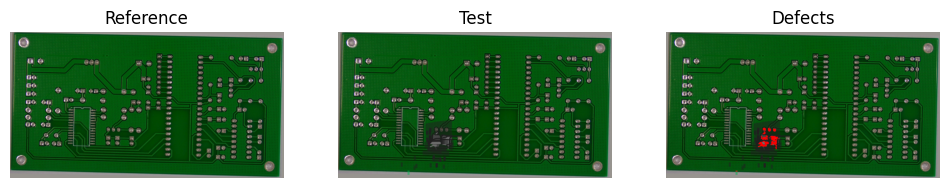

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ref_path = "/content/good pcb.jpg"
test_path = "/content/bad pcb.jpg"

# Read in COLOR
ref = cv2.imread(ref_path)
test = cv2.imread(test_path)

# Resize test to match reference
fx = ref.shape[1] / test.shape[1]
fy = ref.shape[0] / test.shape[0]
test = cv2.resize(test, None, fx=fx, fy=fy)

# Convert to grayscale ONLY for processing
ref_gray = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
test_gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)

# Difference
diff = cv2.absdiff(ref_gray, test_gray)
blur = cv2.GaussianBlur(diff, (5,5), 0)
_, th = cv2.threshold(blur, 30, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)
clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel, iterations=1)

# Overlay defects in RED
overlay = test.copy()
overlay[clean > 0] = [0, 0, 255]

# Convert BGR → RGB for display
ref_rgb = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)
test_rgb = cv2.cvtColor(test, cv2.COLOR_BGR2RGB)
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Reference"); plt.imshow(ref_rgb); plt.axis('off')
plt.subplot(1,3,2); plt.title("Test"); plt.imshow(test_rgb); plt.axis('off')
plt.subplot(1,3,3); plt.title("Defects"); plt.imshow(overlay_rgb); plt.axis('off')
plt.show()


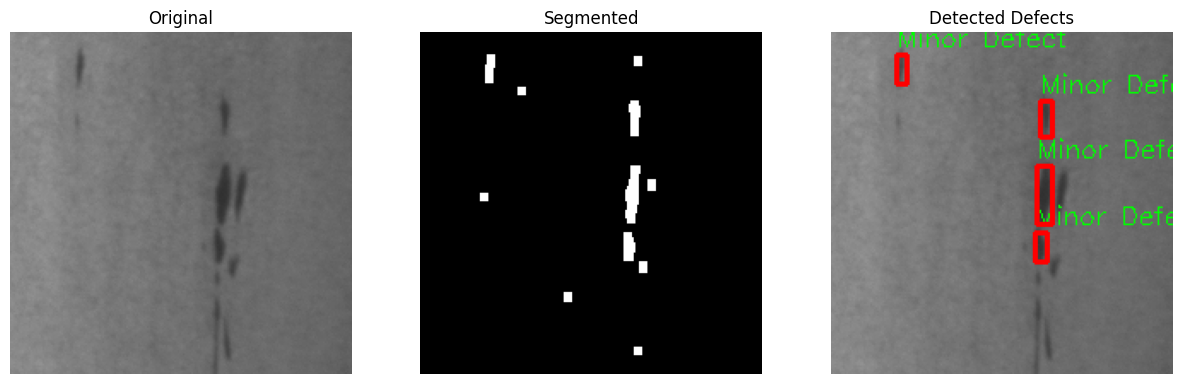

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/In_1.bmp")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray = clahe.apply(gray)

blur = cv2.GaussianBlur(gray, (5,5), 0)

th = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21, 5
)

kernel = np.ones((3,3), np.uint8)
clean = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=2)
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

def classify_defect(cnt):
    area = cv2.contourArea(cnt)
    if area < 50:
        return None

    x,y,w,h = cv2.boundingRect(cnt)
    aspect = w / h if h > 0 else 0
    perimeter = cv2.arcLength(cnt, True)
    hull = cv2.convexHull(cnt)
    solidity = area / cv2.contourArea(hull) if cv2.contourArea(hull) > 0 else 0

    if aspect > 4:
        return "Scratch"
    elif solidity < 0.6:
        return "Crack"
    elif area > 1500:
        return "Blob / Missing"
    else:
        return "Minor Defect"

output = img.copy()

for cnt in contours:
    label = classify_defect(cnt)
    if label:
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x,y), (x+w,y+h), (0,0,255), 2)
        cv2.putText(output, label, (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,3,2); plt.title("Segmented"); plt.imshow(clean, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Detected Defects"); plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()


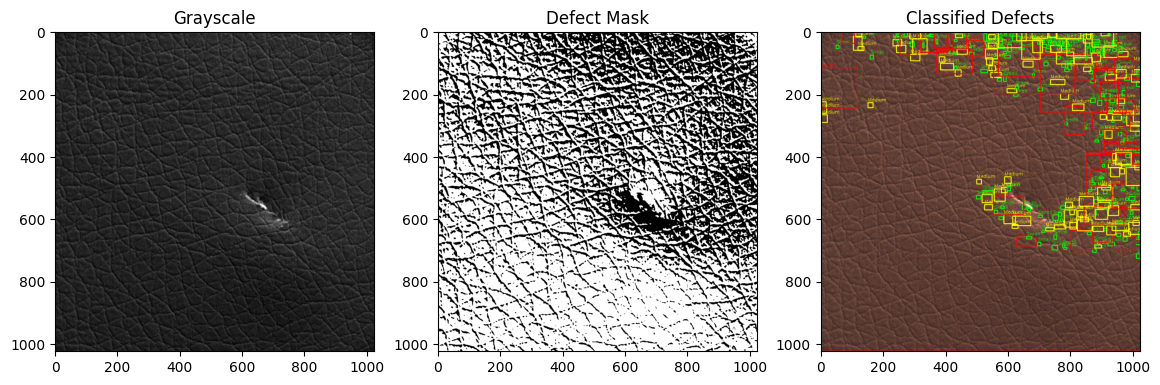

In [1]:
def surface_defect_classification(image_path):
    import cv2, numpy as np, matplotlib.pyplot as plt

    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, mask = cv2.threshold(blur, 0, 255,
                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output = img.copy()

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20:
            continue

        x,y,w,h = cv2.boundingRect(cnt)

        if area < 100:
            label,color = "Small",(0,255,0)
        elif area < 500:
            label,color = "Medium",(0,255,255)
        else:
            label,color = "Large",(0,0,255)

        cv2.rectangle(output,(x,y),(x+w,y+h),color,2)
        cv2.putText(output,label,(x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.5,color,1)

    plt.figure(figsize=(14,5))

    plt.subplot(1,3,1)
    plt.imshow(gray,cmap="gray")
    plt.title("Grayscale")

    plt.subplot(1,3,2)
    plt.imshow(mask,cmap="gray")
    plt.title("Defect Mask")

    plt.subplot(1,3,3)
    plt.imshow(output[:,:,::-1])
    plt.title("Classified Defects")

    plt.show()
surface_defect_classification("/content/008.png")


Found 8 abnormal heating zones.

Max Intensity: 194.0 (Temperature: 80.9°C)
Threshold : 155
Max Temp 76.2°C | Area: 176.5
Max Temp 77.1°C | Area: 584.5
Max Temp 77.4°C | Area: 266.5
Max Temp 69.9°C | Area: 55.0
Max Temp 71.1°C | Area: 68.5
Max Temp 80.9°C | Area: 43831.5
Max Temp 79.3°C | Area: 425.5


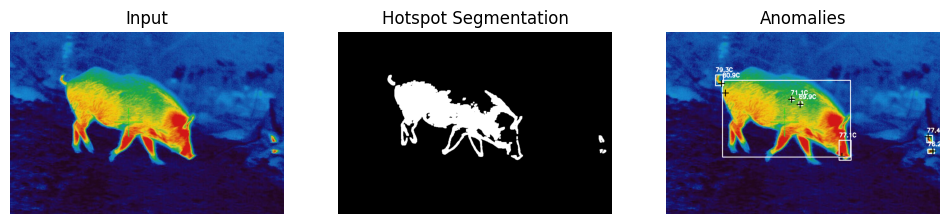

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_hotspots(image, threshold_percent=0.75):

    output = image.copy()

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(gray)

    thresh_value = int(max_val * threshold_percent)

    _, mask = cv2.threshold(gray, thresh_value, 255, cv2.THRESH_BINARY)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    print(f"Found {len(contours)} abnormal heating zones.\n")
    print(f"Max Intensity: {max_val} (Temperature: {map_pixel_to_temp(max_val):.1f}°C)")
    print(f"Threshold : {thresh_value}")

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 50: continue
        x, y, w, h = cv2.boundingRect(cnt)

        roi = gray[y:y+h, x:x+w]
        _, local_max_val, _, local_max_loc = cv2.minMaxLoc(roi)

        temp_c = map_pixel_to_temp(local_max_val)

        cv2.rectangle(output, (x, y), (x + w, y + h), (255, 255, 255), 2)

        global_max_pt = (x + local_max_loc[0], y + local_max_loc[1])
        cv2.drawMarker(output, global_max_pt, (0, 0, 0), cv2.MARKER_CROSS, 20, 2)

        label = f"{temp_c:.1f}C"
        cv2.putText(output, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        print(f"Max Temp {temp_c:.1f}°C | Area: {area}")

    return gray, mask, output

def map_pixel_to_temp(pixel_val, min_temp=20, max_temp=100):

    return min_temp + (pixel_val / 255.0) * (max_temp - min_temp)


input_img=cv2.imread("/content/thermal.jpg")
gray_map, hot_mask, final_result = detect_hotspots(input_img, threshold_percent=0.80)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input")
plt.imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Hotspot Segmentation")
plt.imshow(hot_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Anomalies")
plt.imshow(cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

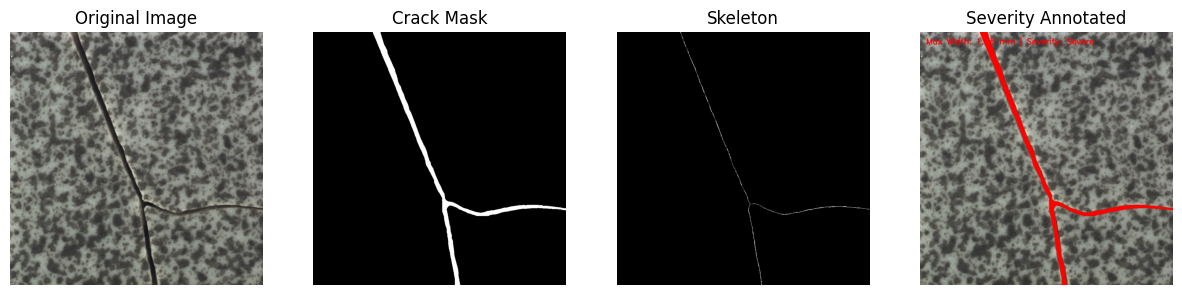

Crack Width Statistics:
  Mean width : 0.721 mm
  Max width  : 1.265 mm
  Severity   : Severe (Class 3)


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

# -----------------------------------
# INPUTS
# -----------------------------------
mask = cv2.imread("/content/000_mask.png", 0)
image = cv2.imread("/content/000.png")
mask = (mask > 0).astype(np.uint8)

# Calibration
MM_PER_PIXEL = 0.05

def skeletonize(binary):
    skel = np.zeros(binary.shape, np.uint8)
    element = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
    done = False

    while not done:
        eroded = cv2.erode(binary, element)
        temp = cv2.dilate(eroded, element)
        temp = cv2.subtract(binary, temp)
        skel = cv2.bitwise_or(skel, temp)
        binary = eroded.copy()
        done = cv2.countNonZero(binary) == 0
    return skel

skeleton = skeletonize(mask.copy())

dist_map = distance_transform_edt(mask)

# Crack width at skeleton points (diameter = 2 * radius)
width_pixels = dist_map[skeleton > 0] * 2
width_mm = width_pixels * MM_PER_PIXEL

mean_width = np.mean(width_mm)
max_width = np.max(width_mm)

def classify_severity(width_mm):
    if width_mm < 0.1:
        return "Hairline", 0
    elif width_mm < 0.3:
        return "Minor", 1
    elif width_mm < 1.0:
        return "Moderate", 2
    else:
        return "Severe", 3

severity_label, severity_class = classify_severity(max_width)

overlay = image.copy()

# Color-code crack by severity
if severity_class == 0:
    color = (0,255,0)
elif severity_class == 1:
    color = (255,255,0)
elif severity_class == 2:
    color = (0,165,255)
else:
    color = (0,0,255)

overlay[mask > 0] = color

cv2.putText(
    overlay,
    f"Max Width: {max_width:.2f} mm | Severity: {severity_label}",
    (20,40),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.9,
    color,
    2
)

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Crack Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Skeleton")
plt.imshow(skeleton, cmap="gray")
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Severity Annotated")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

print("Crack Width Statistics:")
print(f"  Mean width : {mean_width:.3f} mm")
print(f"  Max width  : {max_width:.3f} mm")
print(f"  Severity   : {severity_label} (Class {severity_class})")


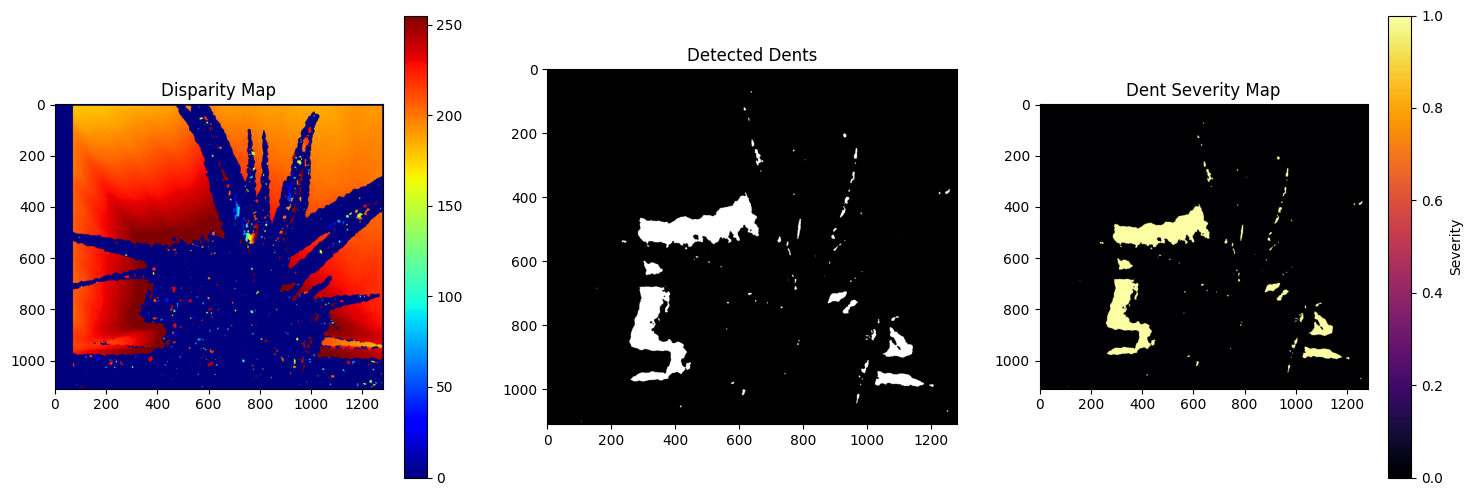

In [3]:
import cv2, numpy as np, matplotlib.pyplot as plt
import urllib.request
left_url  = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aloeL.jpg"
right_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aloeR.jpg"

urllib.request.urlretrieve(left_url, "left.jpg")
urllib.request.urlretrieve(right_url, "right.jpg")

imgL = cv2.imread("left.jpg", cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread("right.jpg", cv2.IMREAD_GRAYSCALE)
imgR = cv2.resize(imgR, (imgL.shape[1], imgL.shape[0]))

stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)
disp = stereo.compute(imgL, imgR).astype(np.float32) / 16.0
disp[disp <= 0] = np.nan

# Smooth disparity
disp_smooth = cv2.medianBlur(np.nan_to_num(disp).astype(np.float32), 5)

median_disp = np.nanmedian(disp_smooth)
depth_diff = np.abs(disp_smooth - median_disp)

# Percentile-based threshold (robust)
thresh = np.nanpercentile(depth_diff, 95)
dents_mask = (depth_diff > thresh).astype(np.uint8) * 255

severity_map = np.zeros_like(disp_smooth, dtype=np.uint8)

severity_map[(depth_diff > thresh) & (depth_diff < thresh*1.5)] = 1.5
severity_map[(depth_diff >= thresh*1.5) & (depth_diff < thresh*2.5)] = 2
severity_map[depth_diff >= thresh*2.5] = 3

disp_vis = cv2.normalize(disp_smooth, None, 0, 255, cv2.NORM_MINMAX)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.title("Disparity Map")
plt.imshow(disp_vis, cmap="jet")
plt.colorbar()

plt.subplot(1,3,2)
plt.title("Detected Dents")
plt.imshow(dents_mask, cmap="gray")

plt.subplot(1,3,3)
plt.title("Dent Severity Map")
plt.imshow(severity_map, cmap="inferno")
plt.colorbar(label="Severity")

plt.show()

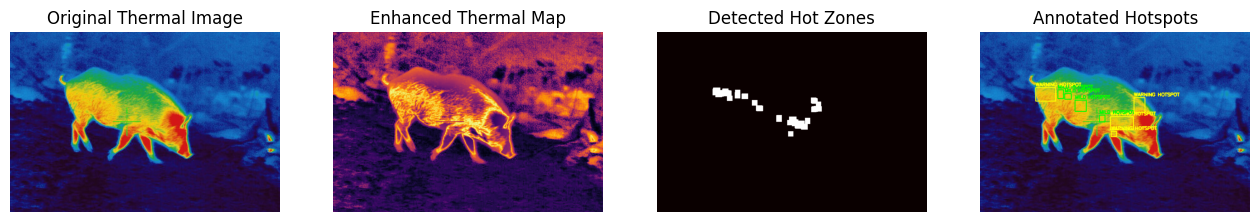

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("/content/thermal.jpg")

# Convert to grayscale temperature proxy
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# VISUAL ENHANCEMENT
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
thermal = clahe.apply(gray)
thermal_blur = cv2.GaussianBlur(thermal, (5,5), 0)

mean_temp = np.mean(thermal_blur)
std_temp = np.std(thermal_blur)

threshold = mean_temp + 2.5 * std_temp

hot_mask = (thermal_blur > threshold).astype(np.uint8) * 255

kernel = np.ones((5,5), np.uint8)
hot_mask = cv2.morphologyEx(hot_mask, cv2.MORPH_OPEN, kernel, iterations=2)
hot_mask = cv2.morphologyEx(hot_mask, cv2.MORPH_DILATE, kernel, iterations=2)

contours, _ = cv2.findContours(hot_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = img.copy()

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 150:
        continue

    x, y, w, h = cv2.boundingRect(cnt)
    roi = thermal_blur[y:y+h, x:x+w]

    peak = np.max(roi)
    avg = np.mean(roi)

    # Severity classification (interpretable)
    if peak > mean_temp + 4*std_temp:
        label = "CRITICAL HOTSPOT"
        color = (0,0,255)
    elif peak > mean_temp + 3*std_temp:
        label = "WARNING HOTSPOT"
        color = (0,255,255)
    else:
        label = "MILD HOTSPOT"
        color = (0,255,0)

    cv2.rectangle(output, (x,y), (x+w,y+h), color, 2)
    cv2.putText(output, label, (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(16,5))

plt.subplot(1,4,1)
plt.title("Original Thermal Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Enhanced Thermal Map")
plt.imshow(thermal, cmap="inferno")
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Detected Hot Zones")
plt.imshow(hot_mask, cmap="hot")
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Annotated Hotspots")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()
